In [1]:
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits.basemap import Basemap

import xarray as xr
import pandas as pd
import cmocean
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import matplotlib.colors as colors

from mpl_toolkits.axes_grid1 import AxesGrid
from mpl_toolkits.basemap import Basemap

In [212]:
# ds1=xr.open_dataset('/media/athira/One Touch/final_datasets/analysis_biascorrected_outputs/ph_ens_ssp245_biascorrected_mean.nc').squeeze()
ds1 = xr.open_dataset('/media/athira/One Touch/final_datasets/Edited_plots/merged_files/ph_ens_ssp126_biascorrected_mean.nc')




# ds1 = xr.open_dataset('/media/athira/One Touch/final_datasets/merged files/pH_ensemble_ssp585_merged.nc').squeeze()

ds1 = 10**(-1*ds1)

ds1 = ds1*10**(9)

lat_range = slice(0, 30)  # Latitude range from -30 to 30
lon_range = slice(38, 78)  # Longitude range from 30 to 100

ds1_hist  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1985', '2014'))#.mean(['lat', 'lon'])
ds1_hist_avg= ds1_hist.mean(['lat', 'lon'])

da = ds1_hist_avg['ph']   # assuming your DataArray is called `ph`
import xrft as xt
# Create numeric time axis
da_detrended = xt.detrend(
    da,
    dim="time",
    detrend_type="linear"
)

In [213]:
def run_lengths_1d(arr):
    if arr.sum() == 0:
        return []

    arr = arr.astype(int)
    diff = np.diff(arr)

    starts = np.where(diff == 1)[0] + 1
    ends   = np.where(diff == -1)[0] + 1

    if arr[0] == 1:
        starts = np.r_[0, starts]
    if arr[-1] == 1:
        ends = np.r_[ends, len(arr)]

    return ends - starts


def duration_metric(da_detrended):
    threshold = da_detrended.quantile(0.95, dim="time")
    extreme = da_detrended >= threshold
    return xr.apply_ufunc(
        lambda x: (
            np.mean([l for l in run_lengths_1d(x) if l >= 2])
            if len([l for l in run_lengths_1d(x) if l >= 2]) > 0
            else 0
        ),
        extreme,
        input_core_dims=[["time"]],
        vectorize=False,
        output_dtypes=[float]
    )


In [214]:
# mean_extreme_duration = duration_metric(da_detrended)
# print("Mean extreme-event duration (months):", float(mean_extreme_duration))
mean_duration = duration_metric(
    da_detrended=da_detrended,        
    # da_detrended=da_detrended,   
    # time_dim="time"
)

In [215]:
mean_duration 

<xarray.DataArray 'ph' ()> Size: 8B
array(0)
Coordinates:
    DEPTH1_1  float32 4B ...
    TIME      datetime64[ns] 8B ...
    lev       float64 8B ...
    olevel    float32 4B ...
    quantile  float64 8B 0.95

In [222]:

ds1_nf  = ds1.sel(lat=lat_range, lon=lon_range, time=slice('2015', '2040'))#.mean(['lat', 'lon'])
ds1_nf_avg= ds1_nf.mean(['lat', 'lon'])

da_nf = ds1_nf_avg['ph']   # assuming your DataArray is called `ph`
import xrft as xt
# Create numeric time axis
da_detrended_nf = xt.detrend(
    da_nf,
    dim="time",
    detrend_type="linear"
)

In [223]:
def run_lengths_1d(arr):
    if arr.sum() == 0:
        return []

    arr = arr.astype(int)
    diff = np.diff(arr)

    starts = np.where(diff == 1)[0] + 1
    ends   = np.where(diff == -1)[0] + 1

    if arr[0] == 1:
        starts = np.r_[0, starts]
    if arr[-1] == 1:
        ends = np.r_[ends, len(arr)]

    return ends - starts


def duration_metric(da_detrended_nf):
    # 1. Threshold from detrended data
    threshold = da_detrended.quantile(0.95, dim="time")

    # 2. Extreme events (binary)
    extreme = da_detrended_nf >= threshold

    # 3. Mean duration of consecutive extremes (>= 2 months only)
    return xr.apply_ufunc(
        lambda x: (
            np.mean([l for l in run_lengths_1d(x) if l >= 2])
            if len([l for l in run_lengths_1d(x) if l >= 2]) > 0
            else 0
        ),
        extreme,
        input_core_dims=[["time"]],
        vectorize=False,
        output_dtypes=[float]
    )


In [224]:
mean_extreme_duration_nf = duration_metric(da_detrended_nf)
print("Mean extreme-event duration (months):", float(mean_extreme_duration_nf))


Mean extreme-event duration (months): 0.0


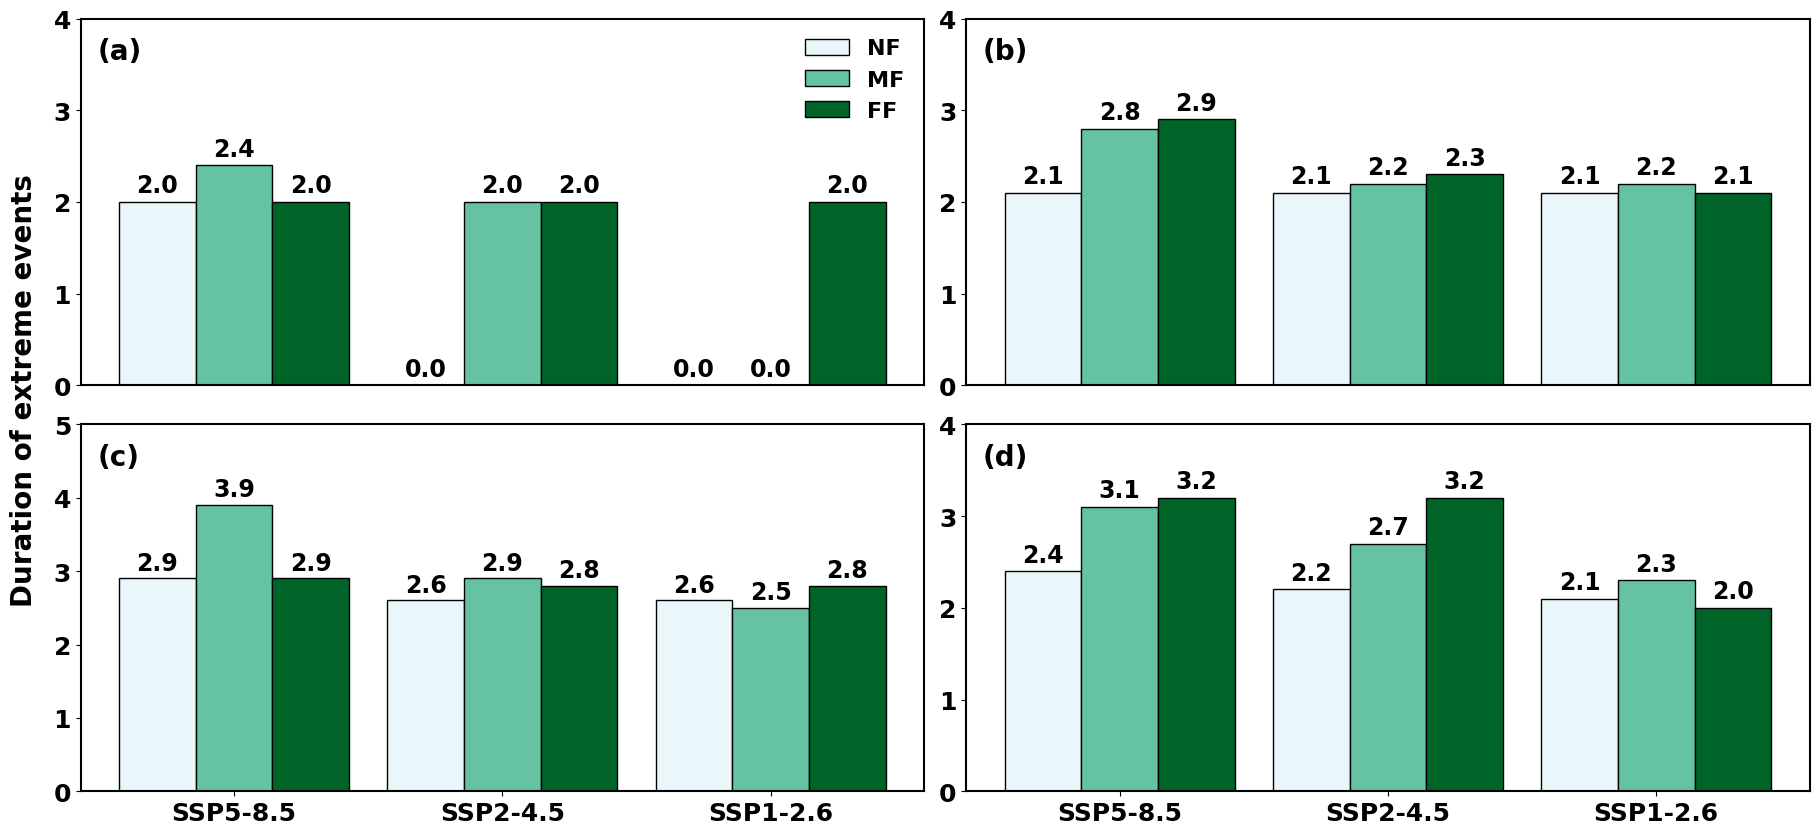

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Global style
# -----------------------------
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'

# -----------------------------
# Data
# -----------------------------
scenarios = ['SSP5-8.5', 'SSP2-4.5', 'SSP1-2.6']
periods   = ['NF', 'MF', 'FF']

# colors = {
#     'NF': '#56B4E9',
#     'MF': '#009E73',
#     'FF': '#D55E00'
# }
cmap = plt.get_cmap('BuGn')
color_list = cmap(np.linspace(0.1, 0.9, 3))
colors = dict(zip(periods, color_list))


data = {
    'AS': {
        'SSP5-8.5': [2.0, 2.4, 2.0],
        'SSP2-4.5': [0, 2.0, 2.0],
        'SSP1-2.6': [0, 0, 2.0]
    },
    'BOB': {
        'SSP5-8.5': [2.1, 2.8, 2.9],
        'SSP2-4.5': [2.1, 2.2, 2.3],
        'SSP1-2.6': [2.1, 2.2, 2.1]
    },
    'EIO': {
        'SSP5-8.5': [2.9, 3.9, 2.9],
        'SSP2-4.5': [2.6, 2.9, 2.8],
        'SSP1-2.6': [2.6, 2.5, 2.8]
    },
    'SIO': {
        'SSP5-8.5': [2.4, 3.1, 3.2],
        'SSP2-4.5': [2.2, 2.7, 3.2],
        'SSP1-2.6': [2.1, 2.3, 2.0]
    }
}

panel_labels = ['(a)', '(b)', '(c)', '(d)']

# -----------------------------
# Plot setup
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(19, 9))  # removed sharey
plt.subplots_adjust(wspace=0.06, hspace=0.2)

axes = axes.flatten()

bar_width = 0.2
x = np.array([0.0, 0.7, 1.4])

# -----------------------------
# Plot
# -----------------------------
for idx, (ax, (region, region_data)) in enumerate(zip(axes, data.items())):

    row = idx // 2
    col = idx % 2

    for i, period in enumerate(periods):
        values = [region_data[sc][i] for sc in scenarios]

        bars = ax.bar(
            x + i * bar_width,
            values,
            width=bar_width,
            color=colors[period],
            edgecolor='black',
            linewidth=1.0,
            label=period
        )

        # Value labels
        for bar in bars:
            h = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.05,
                f'{h:.1f}',
                ha='center',
                va='bottom',
                fontsize=17,
                fontweight='bold'
            )

    # Panel labels
    ax.text(
        0.02, 0.95,
        panel_labels[idx],
        transform=ax.transAxes,
        fontsize=20,
        fontweight='bold',
        va='top'
    )

    # -----------------------------
    # Y-limits and ticks (individual)
    # -----------------------------
    if idx in [0, 1]:  # AS, BOB
        ax.set_ylim(0, 4)
        ax.set_yticks(np.arange(0, 4.1, 1))
    elif idx == 2:  # EIO
        ax.set_ylim(0, 5)
        ax.set_yticks(np.arange(0, 5.1, 1))
    else:  # SIO
        ax.set_ylim(0, 4)
        ax.set_yticks(np.arange(0, 4.1, 1))

    ax.tick_params(axis='y', labelsize=18)

    # -----------------------------
    # X-axis ticks
    # -----------------------------
    if row == 1:
        ax.set_xticks(x + bar_width)
        ax.set_xticklabels(scenarios, fontsize=18, fontweight='bold')
    else:
        ax.set_xticks([])

    # Spine styling
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

# -----------------------------
# Common label & legend
# -----------------------------
fig.text(
    0.045, 0.56,
    'Duration of extreme events',
    va='center',
    rotation='vertical',
    fontsize=20,
    fontweight='bold'
)

axes[0].legend(fontsize=16, frameon=False)

# -----------------------------
# Save & show
# -----------------------------
plt.tight_layout(rect=[0.06, 0.06, 1, 1])
# plt.savefig(
#     "Duration_extreme_events_r1.png",
#     dpi=300,
#     bbox_inches="tight"
# )
plt.show()